In [1]:
import pyspedas
import pytplot
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.cm as cm
# %matplotlib tk

import scipy
from scipy import interpolate,optimize
from scipy.optimize import curve_fit
from skimage.transform import probabilistic_hough_line

import helper
from helper import UTC_to_UNX
from helper import UNX_to_UTC
from helper import find_closest_index_dt

import math
from scipy.interpolate import interp1d
from numpy.linalg import LinAlgError

In [3]:
from detection_helper import *

In [5]:
times_arr, freq_arr, data_arr = return_arr('2023-08-19', '2023-08-20')

27-Jan-26 21:19:16: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
27-Jan-26 21:19:16: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
27-Jan-26 21:19:17: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_hfr/2023/
27-Jan-26 21:19:17: File is current: psp_data/fields/l3/rfs_hfr/2023/psp_fld_l3_rfs_hfr_20230819_v03.cdf
27-Jan-26 21:19:17: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
27-Jan-26 21:19:17: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf
27-Jan-26 21:19:17: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l3/rfs_lfr/2023/
27-Jan-26 21:19:18: File is current: psp_data/fields/l3/rfs_lfr/2023/psp_fld_l3_rfs_lfr_20230819_v03.cdf


In [7]:
freq_log, freq_log_exp, data_arr_log = convert_data_log(freq_arr, data_arr)

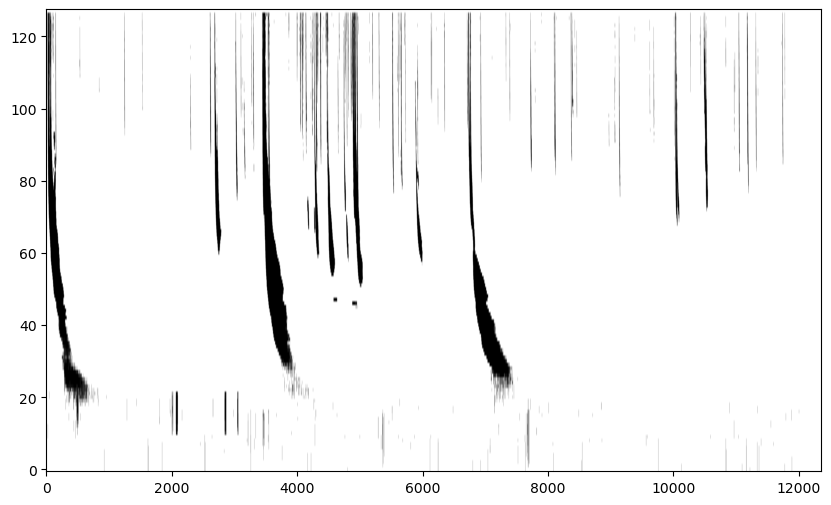

In [9]:
bmap_row_mean = bmap_row_mean_loop_new(times_arr=times_arr, full_data=data_arr_log, min_duration=1)

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

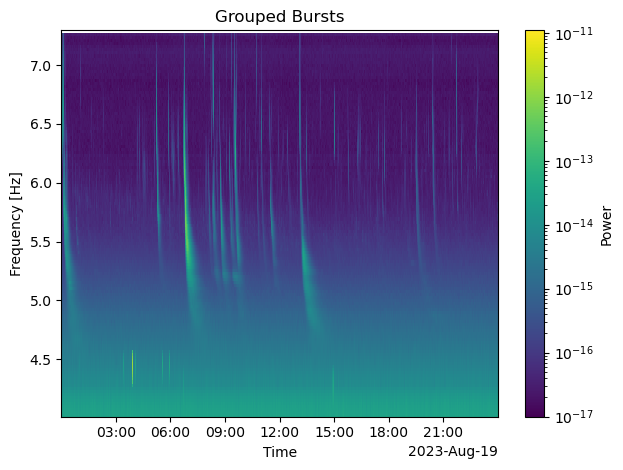

In [11]:
fig, ax = plt.subplots()
p = ax.pcolormesh(times_arr, freq_log_exp, data_arr_log.T, norm=LogNorm())
plt.colorbar(p, label='Power')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
def hough_angle(freq_change, freq_log, time_duration, times_arr):
    # times in second
    # times_arr in UTC
    target_freq = max(freq_log) - freq_change
    target_freq_index = 0
    while target_freq_index < len(freq_log) and freq_log[target_freq_index] < target_freq:
        target_freq_index += 1
    target_freq_index_reverse = len(freq_log) - target_freq_index

    times_arr_UNX = UTC_to_UNX(times_arr)
    target_time = times_arr_UNX[1] + time_duration
    target_time_index = 0
    while target_time_index < len(times_arr_UNX) and times_arr_UNX[target_time_index] < target_time:
        target_time_index += 1

    angle_rad = math.atan2(-target_freq_index_reverse, target_time_index)
    angle_deg = math.degrees(angle_rad) + 90

    return target_freq_index_reverse, target_time_index, angle_deg

freq_change_mean=14718120.082815735
duration_mean=2699.503105590062

target_freq_index_reverse, target_time_index, angle_deg = hough_angle(freq_change_mean, freq_log, duration_mean, times_arr)
target_freq_index_reverse, target_time_index, angle_deg

(25, 388, 86.31335782704286)

In [15]:
bmap_row_mean.shape

(12359, 128)

In [19]:
type(bmap_row_mean)

numpy.ndarray

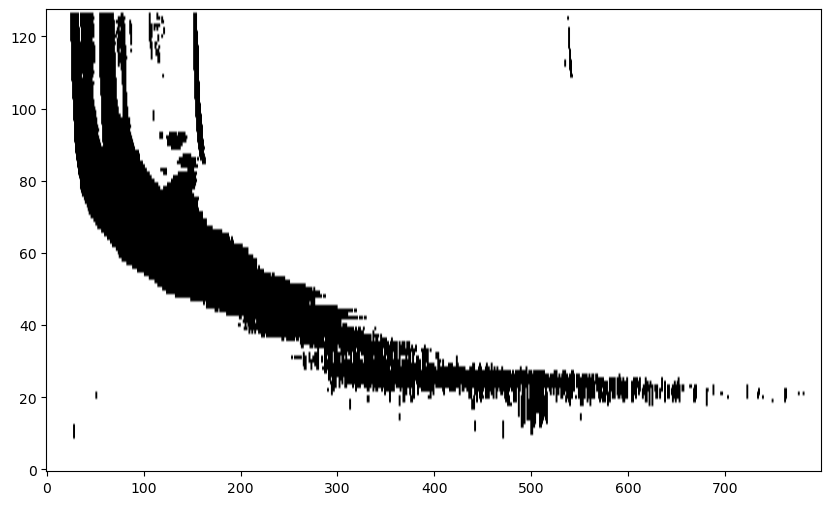

In [141]:
bmap_row_mean_sliced = bmap_row_mean[:800,:]

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean_sliced.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

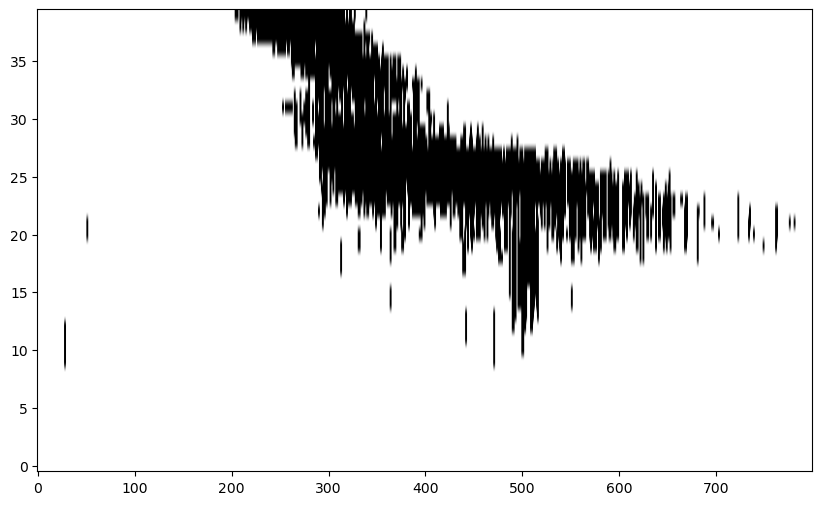

In [499]:
bmap_row_mean_low = bmap_row_mean[:800,:40]

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean_low.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

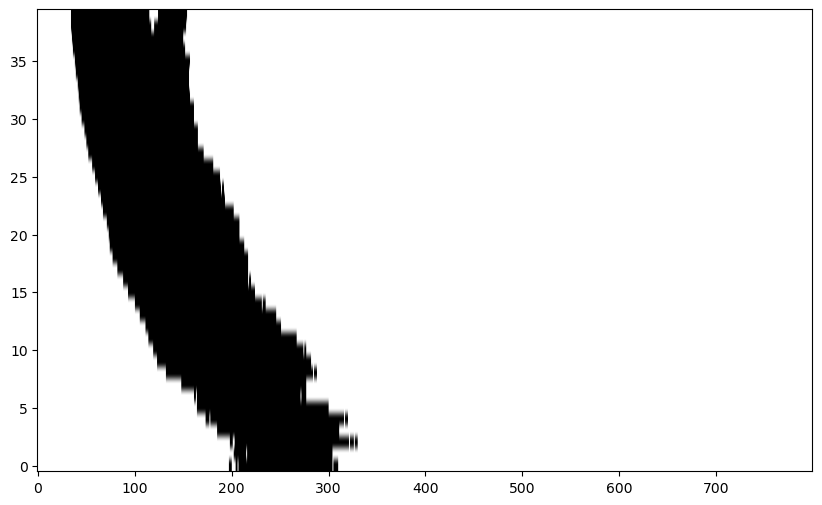

In [207]:
bmap_row_mean_mid = bmap_row_mean[:800,40:80]

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean_mid.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

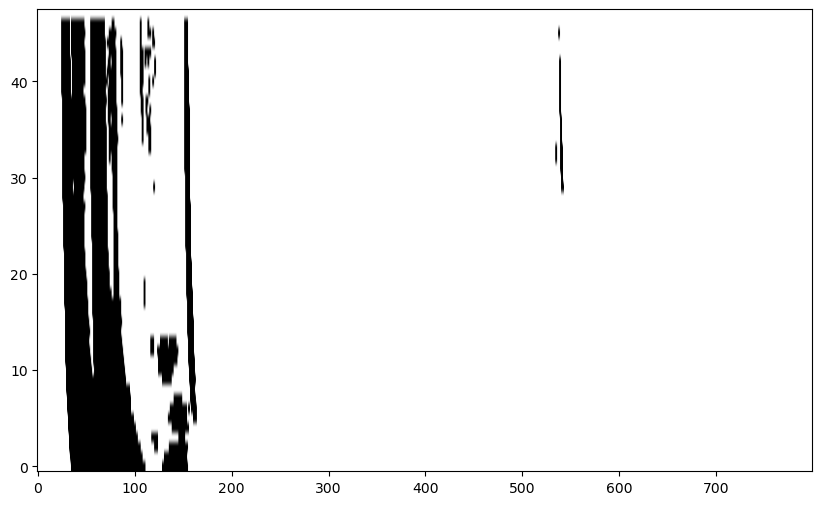

In [135]:
bmap_row_mean_high = bmap_row_mean[:800,80:]

plt.figure(figsize=(10, 6))
plt.imshow(1-bmap_row_mean_high.T, aspect='auto', origin='lower',cmap='gray')
plt.show()

In [471]:
lines = hough_detect(bmap_row_mean_sliced, data_arr_log[:800,:], threshold=1, line_gap=50, line_length=100, theta=np.deg2rad(np.linspace(0, 10, 120)))

time_diff = 1000
freq_diff = 100000000
line_sets, line_sets_actual = line_grouping_new(times_arr, freq_log, lines, time_diff, freq_diff)
line_sets_actual

[(('2023-08-19 00:03:01.586579+00:00', 18071703.899664175),
  ('2023-08-19 00:18:10.354501+00:00', 18071703.899664175)),
 (('2023-08-19 00:03:29.548496+00:00', 2284023.2645684397),
  ('2023-08-19 00:45:05.165226+00:00', 55177.63489052448)),
 (('2023-08-19 00:06:45.283137+00:00', 521265.1388009401),
  ('2023-08-19 00:42:38.364184+00:00', 25592.30030764601)),
 (('2023-08-19 00:08:02.178897+00:00', 411524.7752399553),
  ('2023-08-19 00:59:38.980507+00:00', 32416.94005985867)),
 (('2023-08-19 00:15:29.572501+00:00', 202492.01505329262),
  ('2023-08-19 01:00:20.923627+00:00', 24123.68503423315)),
 (('2023-08-19 00:30:24.359465+00:00', 118964.35082087644),
  ('2023-08-19 01:02:40.734189+00:00', 32416.94005985867)),
 (('2023-08-19 00:31:41.255225+00:00', 69891.72764421279),
  ('2023-08-19 01:10:50.070669+00:00', 41061.49076917933)),
 (('2023-08-19 00:37:30.781142+00:00', 43561.2553120815),
  ('2023-08-19 01:31:13.412112+00:00', 36484.07714377497)),
 (('2023-08-19 00:57:40.141627+00:00', 36484

In [473]:
lines

[((51, 267), (51, 115)),
 ((15, 552), (53, 106)),
 ((73, 156), (93, 29)),
 ((19, 511), (62, 68)),
 ((18, 541), (33, 280)),
 ((90, 162), (90, 30)),
 ((84, 156), (88, 30)),
 ((126, 155), (126, 25)),
 ((42, 330), (80, 35)),
 ((20, 485), (40, 198)),
 ((55, 223), (56, 89)),
 ((14, 517), (50, 132)),
 ((72, 157), (92, 29)),
 ((19, 682), (26, 564)),
 ((21, 493), (55, 94)),
 ((18, 508), (29, 265)),
 ((19, 478), (24, 293)),
 ((50, 277), (69, 49)),
 ((21, 782), (24, 321)),
 ((20, 483), (32, 265)),
 ((15, 517), (82, 33)),
 ((19, 537), (41, 260)),
 ((85, 164), (104, 27)),
 ((23, 607), (32, 271)),
 ((24, 419), (78, 35)),
 ((39, 340), (55, 96)),
 ((62, 202), (79, 35)),
 ((28, 386), (91, 29)),
 ((42, 315), (49, 124)),
 ((31, 391), (70, 46)),
 ((80, 155), (87, 37)),
 ((27, 397), (65, 60)),
 ((40, 276), (58, 78)),
 ((88, 162), (97, 28)),
 ((19, 626), (28, 489)),
 ((105, 158), (125, 41)),
 ((30, 364), (72, 43)),
 ((38, 318), (75, 39)),
 ((59, 204), (87, 31)),
 ((21, 671), (22, 453)),
 ((82, 155), (89, 30

In [475]:
line_sets

[((19, 682), (22, 558)),
 ((19, 682), (22, 558)),
 ((19, 682), (22, 558)),
 ((19, 682), (22, 558)),
 ((19, 682), (22, 558)),
 ((19, 682), (22, 558)),
 ((19, 682), (22, 558)),
 ((19, 682), (22, 557)),
 ((19, 687), (22, 558))]

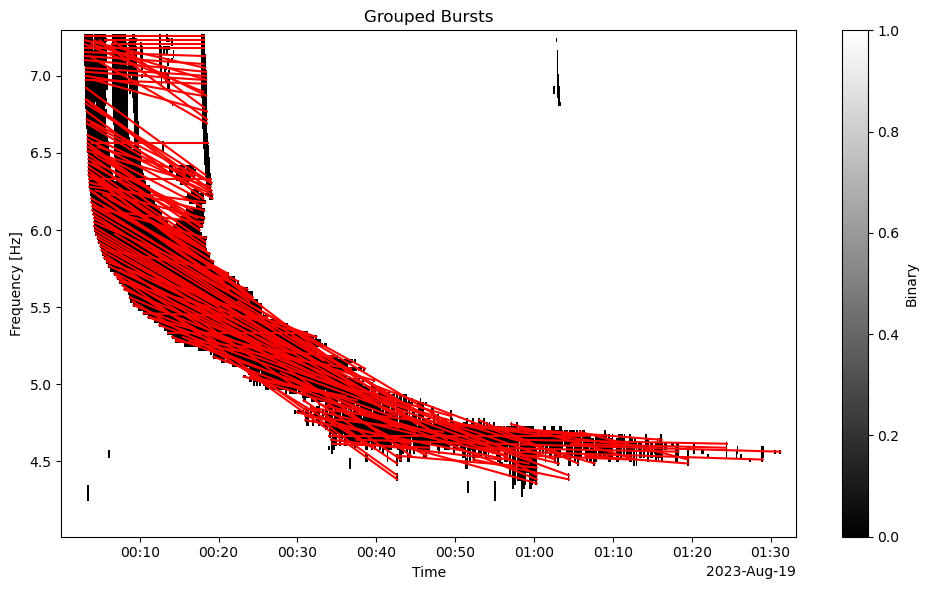

In [477]:
fig, ax = plt.subplots(figsize=(10, 6))
# p = ax.pcolormesh(times_arr, freq_log_exp, data_arr.T, norm=LogNorm())
# p = ax.imshow(1-bmap_row_mean_sliced.T, aspect='auto', origin='lower',cmap='gray')
# plt.colorbar(p, label='Power')

Z = 1 - bmap_row_mean_sliced.T
t = times_arr[:800]
f = freq_log_exp

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

for (x0, y0), (x1, y1) in lines:
    t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

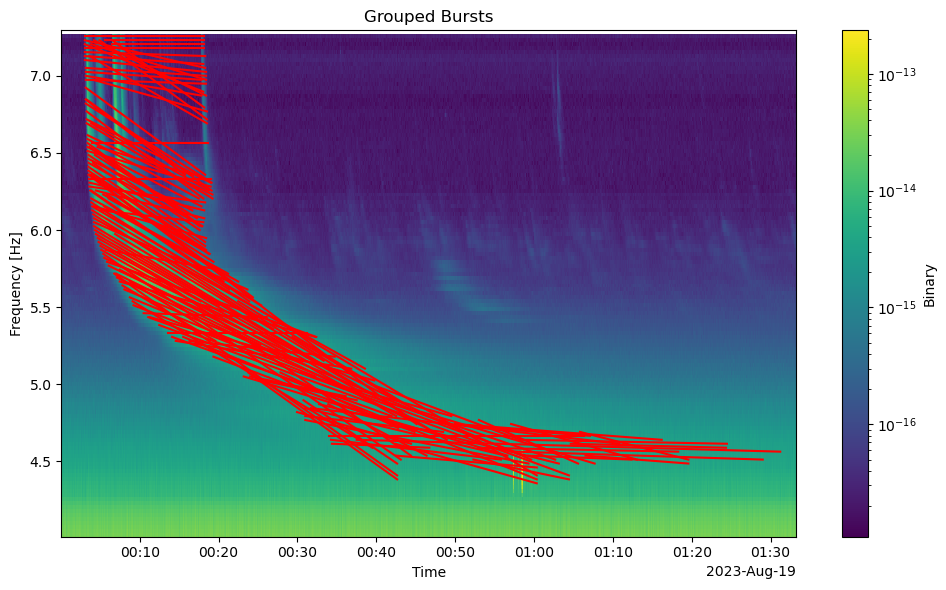

In [479]:
fig, ax = plt.subplots(figsize=(10, 6))

Z = 1 - bmap_row_mean_sliced.T
t = times_arr[:800]
f = freq_log_exp

p = ax.pcolormesh(t, f, data_arr_log[:800].T, norm=LogNorm())
plt.colorbar(p, ax=ax, label="Binary")

for (x0, y0), (x1, y1) in lines:
    t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
    f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

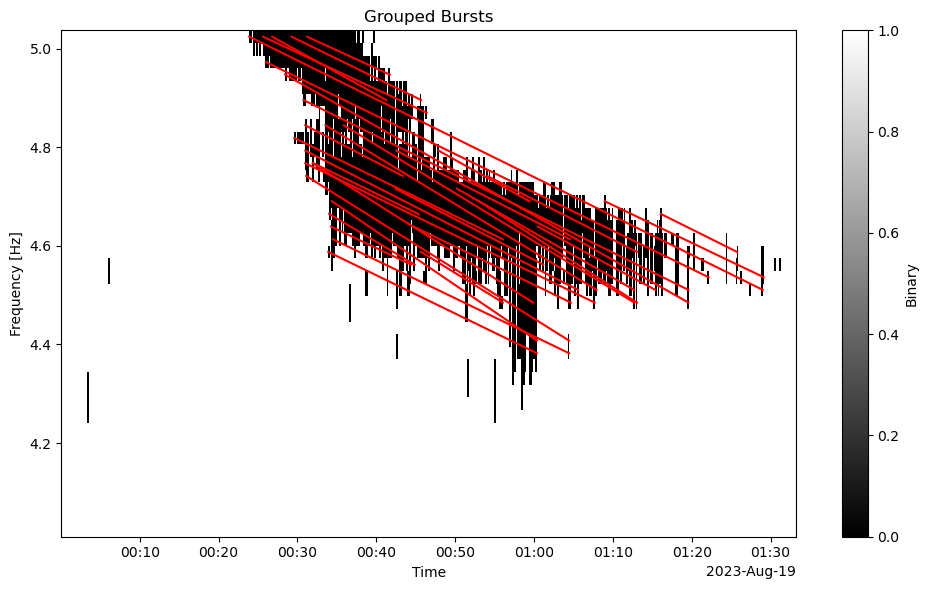

In [501]:
theta = np.deg2rad(np.linspace(2, 3, 120))
lines_low = hough_detect(bmap_row_mean_low, data_arr_log[:800,:], threshold=1, line_gap=70, line_length=80, theta=theta)

fig, ax = plt.subplots(figsize=(10, 6))
# p = ax.pcolormesh(times_arr, freq_log_exp, data_arr.T, norm=LogNorm())
# p = ax.imshow(1-bmap_row_mean_sliced.T, aspect='auto', origin='lower',cmap='gray')
# plt.colorbar(p, label='Power')

Z = 1 - bmap_row_mean_low.T
t = times_arr[:800]
f = freq_log_exp[:40]

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

for (x0, y0), (x1, y1) in lines_low:
    t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
    f0, f1 = freq_log_exp[:40][x0], freq_log_exp[:40][x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [255]:
def longest_line(lines):
    longest_line = None
    longest_length_sqr = 0

    for line in lines:
        (x0, y0), (x1, y1) = line
        dx = x1 - x0
        dy = y1 - y0
        length_sqr = dx*dx + dy*dy
        if length_sqr > longest_length_sqr:
            longest_length_sqr = length_sqr
            longest_line = line

    longest_length = math.sqrt(longest_length_sqr) 
    return longest_line, longest_length_sqr

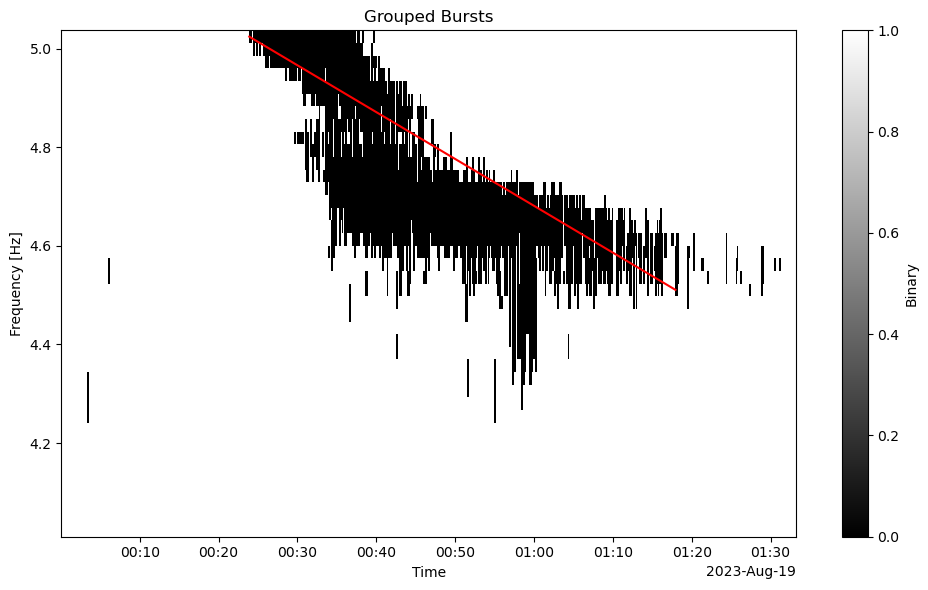

In [503]:
theta = np.deg2rad(np.linspace(2, 10, 120))
lines_low = hough_detect(bmap_row_mean_low, data_arr_log[:800,:], threshold=1, line_gap=30, line_length=90, theta=theta)

longest_line_low, longtest_line_length_low = longest_line(lines_low)

fig, ax = plt.subplots(figsize=(10, 6))
# p = ax.pcolormesh(times_arr, freq_log_exp, data_arr.T, norm=LogNorm())
# p = ax.imshow(1-bmap_row_mean_sliced.T, aspect='auto', origin='lower',cmap='gray')
# plt.colorbar(p, label='Power')

Z = 1 - bmap_row_mean_low.T
t = times_arr[:800]
f = freq_log_exp[:40]

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

(x0, y0), (x1, y1) = longest_line_low
t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[:40][x0], freq_log_exp[:40][x1]
ax.plot([t0, t1], [f0, f1], color='red')


# for (x0, y0), (x1, y1) in lines_low:
#     t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
#     f0, f1 = freq_log_exp[10:40][x0], freq_log_exp[10:40][x1]
#     # print(t0, t1, f0, f1)
#     ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

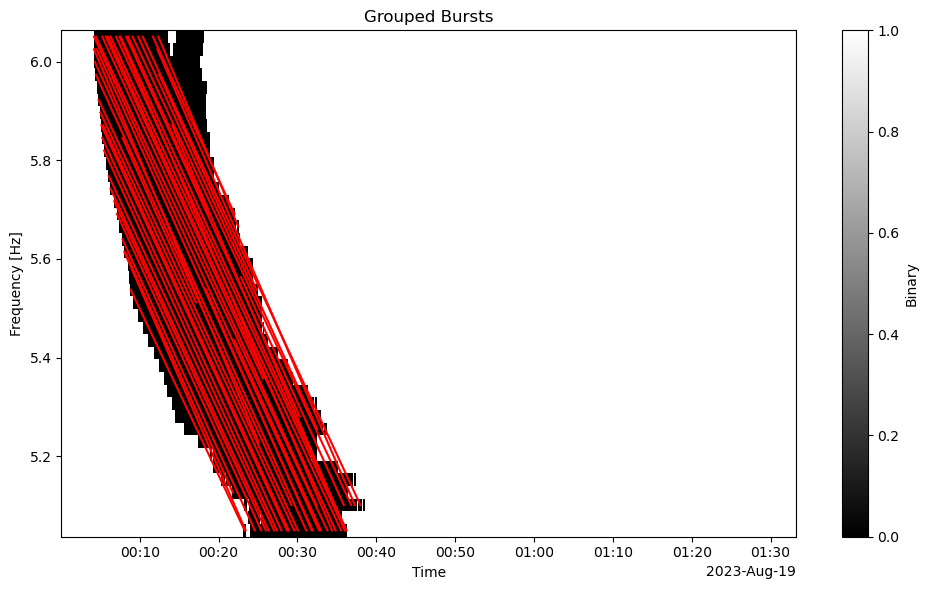

In [221]:
theta=np.deg2rad(np.linspace(9, 10, 120))
lines_low = hough_detect(bmap_row_mean_mid, data_arr_log[:800,:], threshold=1, line_gap=70, line_length=80, theta=theta)

fig, ax = plt.subplots(figsize=(10, 6))
# p = ax.pcolormesh(times_arr, freq_log_exp, data_arr.T, norm=LogNorm())
# p = ax.imshow(1-bmap_row_mean_sliced.T, aspect='auto', origin='lower',cmap='gray')
# plt.colorbar(p, label='Power')

Z = 1 - bmap_row_mean_mid.T
t = times_arr[:800]
f = freq_log_exp[40:80]

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

for (x0, y0), (x1, y1) in lines_low:
    t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
    f0, f1 = freq_log_exp[40:80][x0], freq_log_exp[40:80][x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

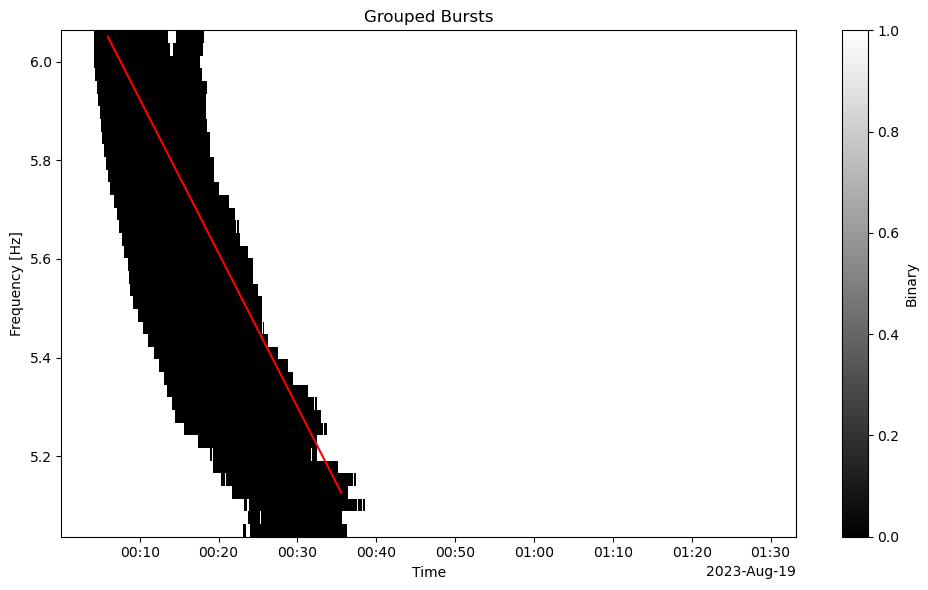

In [439]:
theta = np.deg2rad(np.linspace(5, 10, 120))
lines_mid = hough_detect(bmap_row_mean_mid, data_arr_log[:800,:], threshold=1, line_gap=10, line_length=90, theta=theta)

longest_line_mid, longtest_line_length_mid = longest_line(lines_mid)

fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap_row_mean_mid.T
t = times_arr[:800]
f = freq_log_exp[40:80]
p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

(x0, y0), (x1, y1) = longest_line_mid
t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[40:80][x0], freq_log_exp[40:80][x1]
ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

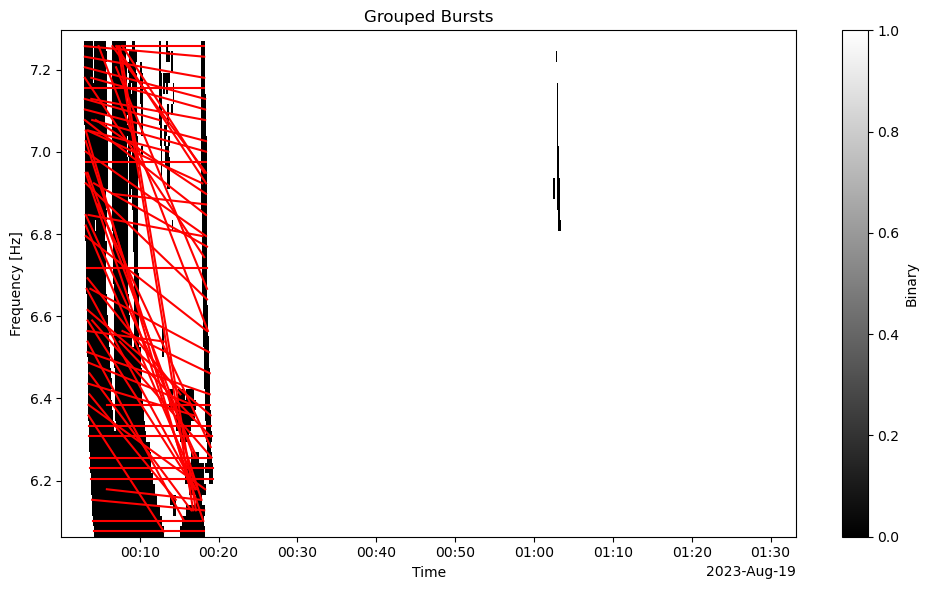

In [371]:
theta=np.deg2rad(np.linspace(0, 31, 120))
lines_high = hough_detect(bmap_row_mean_high, data_arr_log[:800,:], threshold=1, line_gap=70, line_length=80, theta=theta)

fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap_row_mean_high.T
t = times_arr[:800]
f = freq_log_exp[80:]

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

for (x0, y0), (x1, y1) in lines_high:
    t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
    f0, f1 = freq_log_exp[80:][x0], freq_log_exp[80:][x1]
    # print(t0, t1, f0, f1)
    ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

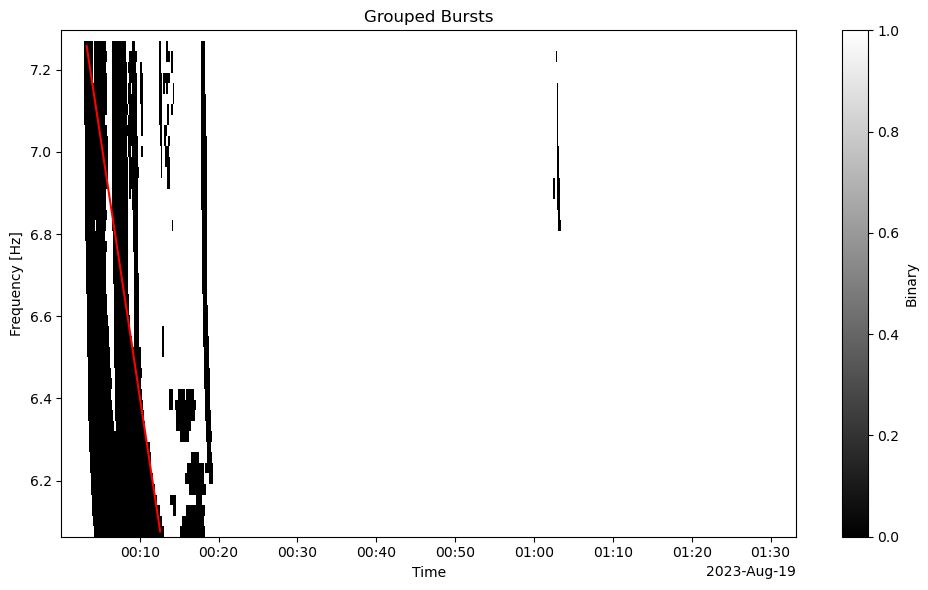

In [437]:
theta=np.deg2rad(np.linspace(30, 31, 1000))
lines_high = hough_detect(bmap_row_mean_high, data_arr_log[:800,:], threshold=1, line_gap=10, line_length=80, theta=theta)
longest_line_high, longtest_line_length_high = longest_line(lines_high)

fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap_row_mean_high.T
t = times_arr[:800]
f = freq_log_exp[80:]

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

(x0, y0), (x1, y1) = longest_line_high
t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[80:][x0], freq_log_exp[80:][x1]
ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

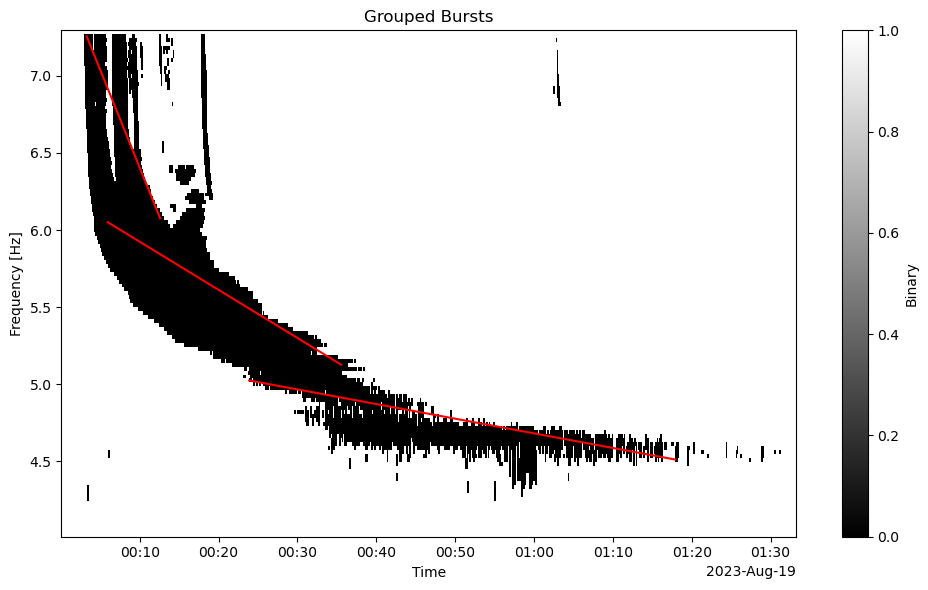

In [507]:
fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap_row_mean_sliced.T
t = times_arr[:800]
f = freq_log_exp

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

(x0, y0), (x1, y1) = longest_line_low
t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[:40][x0], freq_log_exp[:40][x1]
ax.plot([t0, t1], [f0, f1], color='red')

(x0, y0), (x1, y1) = longest_line_mid
t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[40:80][x0], freq_log_exp[40:80][x1]
ax.plot([t0, t1], [f0, f1], color='red')

(x0, y0), (x1, y1) = longest_line_high
t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[80:][x0], freq_log_exp[80:][x1]
ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

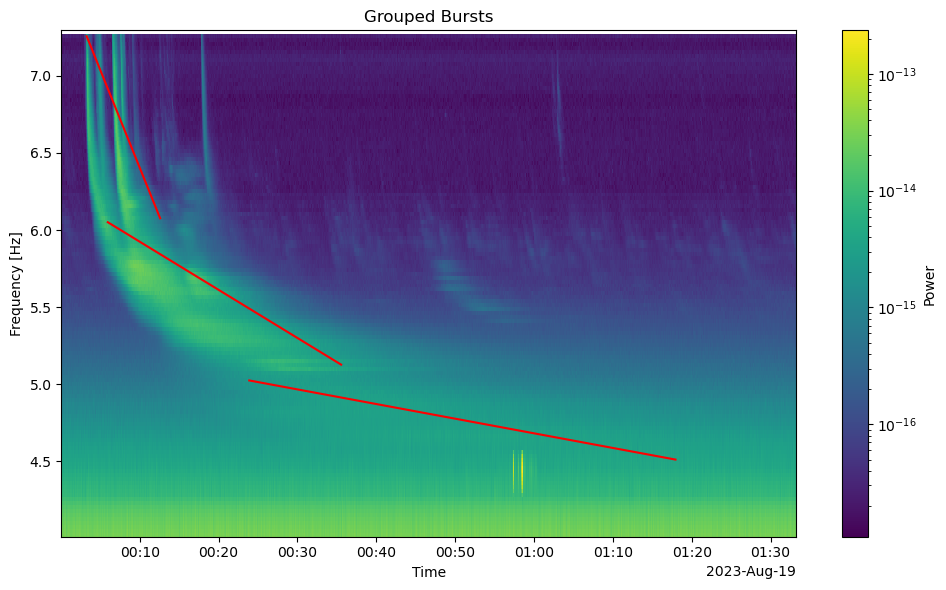

In [505]:
fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap_row_mean_sliced.T
t = times_arr[:800]
f = freq_log_exp

# p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
p = ax.pcolormesh(t, f, data_arr_log[:800].T, norm=LogNorm())
plt.colorbar(p, ax=ax, label="Power")

(x0, y0), (x1, y1) = longest_line_low
t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[:40][x0], freq_log_exp[:40][x1]
ax.plot([t0, t1], [f0, f1], color='red')

(x0, y0), (x1, y1) = longest_line_mid
t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[40:80][x0], freq_log_exp[40:80][x1]
ax.plot([t0, t1], [f0, f1], color='red')

(x0, y0), (x1, y1) = longest_line_high
t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[80:][x0], freq_log_exp[80:][x1]
ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [539]:
(x0, y0), (x1, y1)

((19, 668), (126, 27))

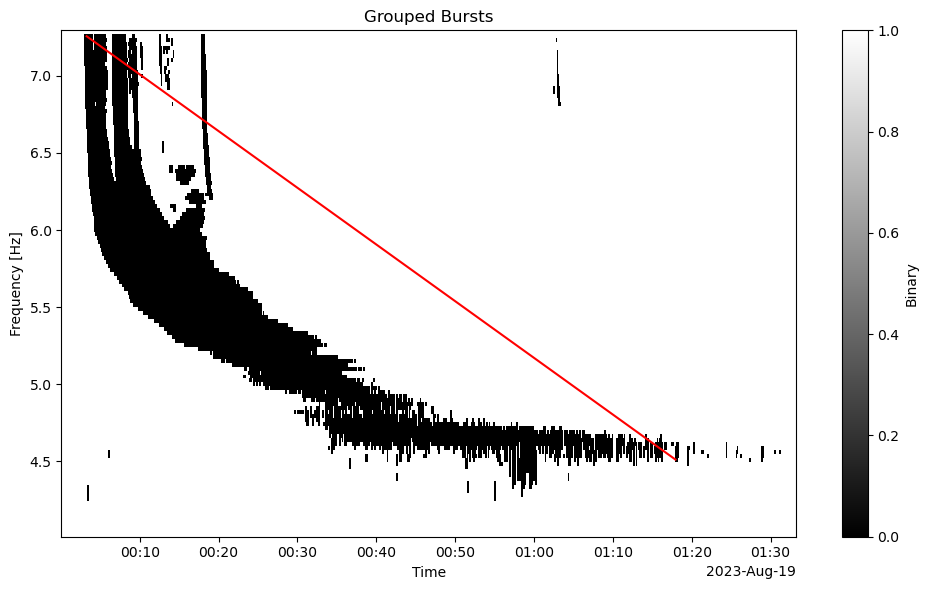

In [531]:
fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap_row_mean_sliced.T
t = times_arr[:800]
f = freq_log_exp

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

(x0_low, y0_low), (x1_low, y1_low) = longest_line_low
(x0_high, y0_high), (x1_high, y1_high) = longest_line_high
(x0, y0), (x1, y1) = (x0_low, y0_low), (x1_high+80, y1_high)

t0, t1 = times_arr[:800][y0], times_arr[:800][y1]
f0, f1 = freq_log_exp[x0], freq_log_exp[x1]
ax.plot([t0, t1], [f0, f1], color='red')

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [449]:
import numpy as np
import numpy.linalg as LA
from scipy.interpolate import interp2d
from scipy.ndimage.filters import gaussian_filter
import numpy.linalg as LA

def PJcurvature(x,y):
    """
    input  : the coordinate of the three point
    output : the curvature and norm direction
    refer to https://github.com/peijin94/PJCurvature for detail
    """
    t_a = LA.norm([x[1]-x[0],y[1]-y[0]])
    t_b = LA.norm([x[2]-x[1],y[2]-y[1]])

    M = np.array([
        [1, -t_a, t_a**2],
        [1, 0,    0     ],
        [1,  t_b, t_b**2]])

    a = np.matmul(LA.pinv(M),x)
    b = np.matmul(LA.pinv(M),y)

    kappa = 2*(a[2]*b[1]-b[2]*a[1])/(a[1]**2.+b[1]**2.)**(1.5)
    return kappa, [b[1],-a[1]]/np.sqrt(a[1]**2.+b[1]**2.)


def ACBone(img,x,y,x0,y0,n_iter = 200,d_step=0.2,alpha=25,beta=6000,y_gap=90.,blur_sigma=2.5):
        # print((y0[0]),(y0[1]))
        N=int(abs(y0[1]-y0[0])/y_gap)
        N=300
        yy = np.linspace((y0[0]),(y0[1]), 300)
        # print(int(abs(y0[1]-y0[0])/y_gap))
        # print(yy)
        xx = np.linspace((x0[0]),(x0[1]), len(yy))# +  np.random.normal(0, 0.1, len(yy))
        # print("\n[INIT]")
        # print("x0=", x0, "y0=", y0)
        # print("y_gap=", y_gap, "dy=", float(abs(y0[1]-y0[0])))
        # print("N=", len(xx))
        # print("xx head/tail:", xx[:3], xx[-3:])
        # print("yy head/tail:", yy[:3], yy[-3:])
        # print("finite xx?", np.isfinite(xx).all(), "finite yy?", np.isfinite(yy).all())

        # blurred = gaussian_filter(img, sigma=blur_sigma)
        blurred = img

        Grad_x = interp2d(x, y, np.gradient(img,axis=1)/(np.max(np.gradient(img,axis=1))), kind='quintic')
        Grad_y = interp2d(x, y, np.gradient(img,axis=0)/(np.max(np.gradient(img,axis=0))), kind='quintic')


        Grad_x_blur = interp2d(x, y, np.gradient(blurred,axis=1)/(np.max(np.gradient(blurred,axis=1))), kind='quintic')
        Grad_y_blur = interp2d(x, y, np.gradient(blurred,axis=0)/(np.max(np.gradient(blurred,axis=0))), kind='quintic')

        xx_new = xx
        yy_new = yy

        idx_img=0
        # print(n_iter)
        for step in range(n_iter):
            kappa_arr = np.zeros(len(xx))
            norm_arr  = np.zeros([len(xx),2])
            # print('kappa_arr')
            # print(kappa_arr)    
            # print('norm_arr')
            # print(norm_arr)
            
            # print('xx')
            # print(xx[1:-1])
            # print(xx)
            for idx,val in enumerate(xx[1:-1]):
                # print('idx')
                # print(idx)
                # print('val')
                # print(val)
                ytmp = yy_new[idx:idx+3]
                # print('ytmp')
                # print(ytmp)
                xtmp = xx_new[idx:idx+3]
                # print('xtmp')
                # print(xtmp)
                try: 
                    kappa,norm_l = PJcurvature(xtmp,ytmp)
                    kappa_arr[idx+1] = kappa
                    norm_arr[idx+1,:] = norm_l
                except LinAlgError:
                    pass
                
            # print('kappa_arr')
            # print(kappa_arr)    
            # print('norm_arr')
            # print(norm_arr)
            
            # plt.plot(xx_new,kappa_arr)
            # plt.show()
            # plt.plot(xx_new,norm_arr)
            # plt.show()
            
            f_x = beta* kappa_arr*norm_arr[:,0]
            f_x[-1] = -f_x[-2]
            f_x[0] = -f_x[1]
            if step>n_iter/3.5 :
                xx_new = xx_new+ d_step* (alpha * np.array([Grad_x(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0] + f_x)
            else:
                xx_new = xx_new+ d_step* (alpha * np.array([Grad_x_blur(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0] + f_x)

            #print(alpha * np.array([Grad_x_blur(xx_new[i],yy_new[i])
            #                for i in np.arange(len(xx_new))])[:,0])
            #yy_new = yy_new+ d_step/1000* (alpha * np.array([Grad_y(xx_new[i],yy_new[i])
            #                                            for i in np.arange(len(xx_new))])[:,0])

        img_xy = interp2d(x, y, img, kind='quintic')
        flux = np.array([img_xy(xx_new[i],yy_new[i])
                            for i in np.arange(len(xx_new))])[:,0]

        return xx_new,yy_new,flux

In [609]:
img = data_arr_log[:800,:].T[:-1]
# x = UTC_to_UNX(times_arr)[:800]
x = times_arr[:800]
y = freq_log[:-1]

In [842]:
times_arr

array(['2023-08-19T00:00:06.823376640', '2023-08-19T00:00:13.814100096',
       '2023-08-19T00:00:20.804579456', ...,
       '2023-08-19T23:59:41.724707712', '2023-08-19T23:59:48.715186944',
       '2023-08-19T23:59:55.705910400'], dtype='datetime64[ns]')

In [878]:
img = data_arr_log.T[:-1]
x = UTC_to_UNX(times_arr)
y = freq_log[:-1]

In [886]:
longest_line_high

((0, 107), (46, 27))

In [888]:
(x0, y0), (x1, y1) = longest_line_high
y0=y0+80
y1=y1+80
(x0, y0), (x1, y1)

((0, 187), (46, 107))

In [890]:
x_init = (x[y1], x[y0])
y_init = (y[x1], y[x0])
x_init, y_init

((1692403954.809298, 1692404514.051303),
 (159861.98726885096, 10546.885178850274))

In [892]:
xx, yy, flux = ACBone(img, x, y, x_init, y_init, n_iter = 50)
xx, yy, flux

(array([1.69240395e+09, 1.69240396e+09, 1.69240396e+09, 1.69240396e+09,
        1.69240396e+09, 1.69240396e+09, 1.69240397e+09, 1.69240397e+09,
        1.69240397e+09, 1.69240397e+09, 1.69240397e+09, 1.69240398e+09,
        1.69240398e+09, 1.69240398e+09, 1.69240398e+09, 1.69240398e+09,
        1.69240398e+09, 1.69240399e+09, 1.69240399e+09, 1.69240399e+09,
        1.69240399e+09, 1.69240399e+09, 1.69240400e+09, 1.69240400e+09,
        1.69240400e+09, 1.69240400e+09, 1.69240400e+09, 1.69240401e+09,
        1.69240401e+09, 1.69240401e+09, 1.69240401e+09, 1.69240401e+09,
        1.69240401e+09, 1.69240402e+09, 1.69240402e+09, 1.69240402e+09,
        1.69240402e+09, 1.69240402e+09, 1.69240403e+09, 1.69240403e+09,
        1.69240403e+09, 1.69240403e+09, 1.69240403e+09, 1.69240404e+09,
        1.69240404e+09, 1.69240404e+09, 1.69240404e+09, 1.69240404e+09,
        1.69240404e+09, 1.69240405e+09, 1.69240405e+09, 1.69240405e+09,
        1.69240405e+09, 1.69240405e+09, 1.69240406e+09, 1.692404

<Figure size 1000x600 with 0 Axes>

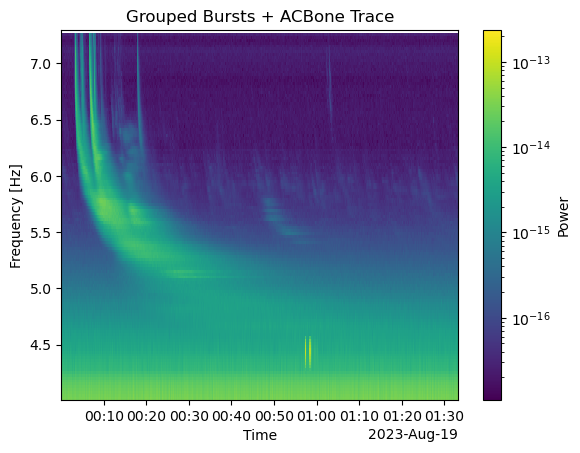

In [717]:
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots()

t = times_arr[:800]
f = freq_log_exp

p = ax.pcolormesh(t, f, data_arr_log[:800].T, norm=LogNorm())

plt.colorbar(p, ax=ax, label='Power')

# ax.plot(UNX_to_UTC(xx), yy, 'r-', color='red')
# ax.plot(UNX_to_UTC(x_init), y_init, 'r-', color='orange')

ax.set_xlabel("Time")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("Grouped Bursts + ACBone Trace")
# ax.set_yscale('log')

# plt.tight_layout()
plt.show()

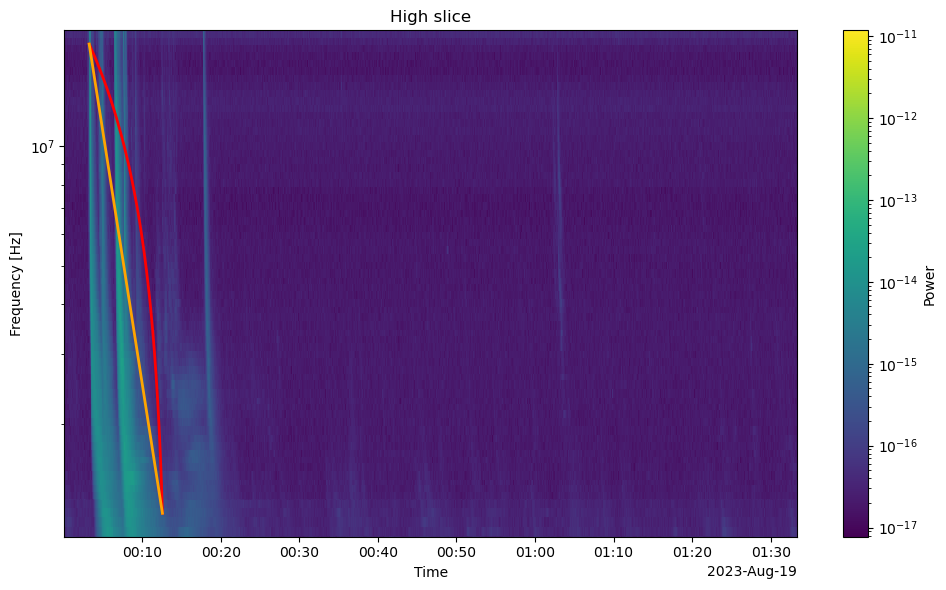

In [733]:
fig, ax = plt.subplots(figsize=(10, 6))

p = ax.pcolormesh(times_arr, freq_arr, data_arr.T, norm=LogNorm(), shading="auto")
plt.colorbar(p, ax=ax, label="Power")

ax.plot(UNX_to_UTC(xx), yy, color="red", lw=2)

ax.plot(UNX_to_UTC(np.array(x_init)), np.array(y_init), color="orange", lw=2)

ax.set_xlim(times_arr[0], times_arr[800])
ax.set_yscale("log")
ax.set_xlabel("Time")
ax.set_ylabel("Frequency [Hz]")
ax.set_title("High slice")
plt.tight_layout()
plt.show()

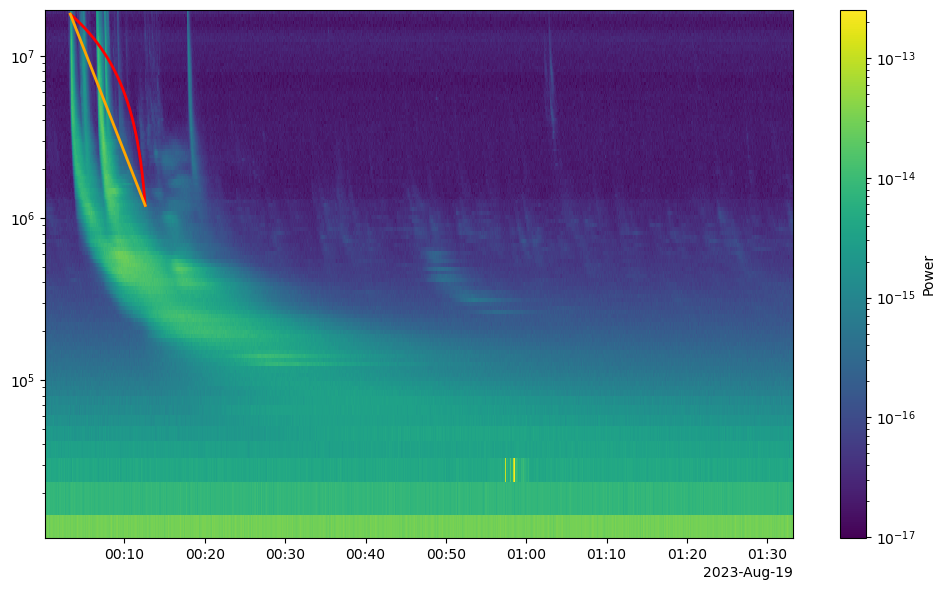

In [808]:
t_plot = times_arr[:800]
Z_plot = data_arr[:800, :].T

fig, ax = plt.subplots(figsize=(10, 6))
m = ax.pcolormesh(t_plot, freq_arr, Z_plot, norm=LogNorm(), shading="auto")
plt.colorbar(m, ax=ax, label="Power")

ax.plot(UNX_to_UTC(xx), yy, color="red", lw=2)
ax.plot(UNX_to_UTC(np.array(x_init)), np.array(y_init), color="orange", lw=2)

ax.set_xlim(t_plot[0], t_plot[-1])
ax.set_yscale("log")
ax.set_ylim(freq_arr.min(), freq_arr.max())
plt.tight_layout()
plt.show()

In [735]:
times_arr

array(['2023-08-19T00:00:06.823376640', '2023-08-19T00:00:13.814100096',
       '2023-08-19T00:00:20.804579456', ...,
       '2023-08-19T23:59:41.724707712', '2023-08-19T23:59:48.715186944',
       '2023-08-19T23:59:55.705910400'], dtype='datetime64[ns]')

In [737]:
times_arr[::-1]

array(['2023-08-19T23:59:55.705910400', '2023-08-19T23:59:48.715186944',
       '2023-08-19T23:59:41.724707712', ...,
       '2023-08-19T00:00:20.804579456', '2023-08-19T00:00:13.814100096',
       '2023-08-19T00:00:06.823376640'], dtype='datetime64[ns]')

In [741]:
img = data_arr_log.T[:-1][::-1]
x = UTC_to_UNX(times_arr)[::-1]
y = freq_log[:-1][::-1]

In [880]:
xx, yy, flux = ACBone(img, x, y, x_init, y_init, n_iter = 50)
xx, yy, flux

(array([1.69248419e+09, 1.69248419e+09, 1.69248420e+09, 1.69248420e+09,
        1.69248420e+09, 1.69248420e+09, 1.69248420e+09, 1.69248421e+09,
        1.69248421e+09, 1.69248421e+09, 1.69248421e+09, 1.69248421e+09,
        1.69248421e+09, 1.69248422e+09, 1.69248422e+09, 1.69248422e+09,
        1.69248422e+09, 1.69248422e+09, 1.69248423e+09, 1.69248423e+09,
        1.69248423e+09, 1.69248423e+09, 1.69248423e+09, 1.69248424e+09,
        1.69248424e+09, 1.69248424e+09, 1.69248424e+09, 1.69248424e+09,
        1.69248424e+09, 1.69248425e+09, 1.69248425e+09, 1.69248425e+09,
        1.69248425e+09, 1.69248425e+09, 1.69248426e+09, 1.69248426e+09,
        1.69248426e+09, 1.69248426e+09, 1.69248426e+09, 1.69248426e+09,
        1.69248427e+09, 1.69248427e+09, 1.69248427e+09, 1.69248427e+09,
        1.69248427e+09, 1.69248428e+09, 1.69248428e+09, 1.69248428e+09,
        1.69248428e+09, 1.69248428e+09, 1.69248429e+09, 1.69248429e+09,
        1.69248429e+09, 1.69248429e+09, 1.69248429e+09, 1.692484

In [848]:
t_plot[0]

numpy.datetime64('2023-08-19T00:00:06.823376640')

In [854]:
t_plot[-1]

numpy.datetime64('2023-08-19T01:33:12.250992768')

In [850]:
xx[0]

1692484192.0310497

In [852]:
UNX_to_UTC(xx[0])

datetime.datetime(2023, 8, 19, 22, 29, 52, 31050, tzinfo=datetime.timezone.utc)

In [856]:
UNX_to_UTC(xx[-1])

datetime.datetime(2023, 8, 19, 22, 39, 11, 272851, tzinfo=datetime.timezone.utc)

In [860]:
yy[0]

16057123.76350689

In [862]:
freq_log_exp[0]

4.0231242179870605

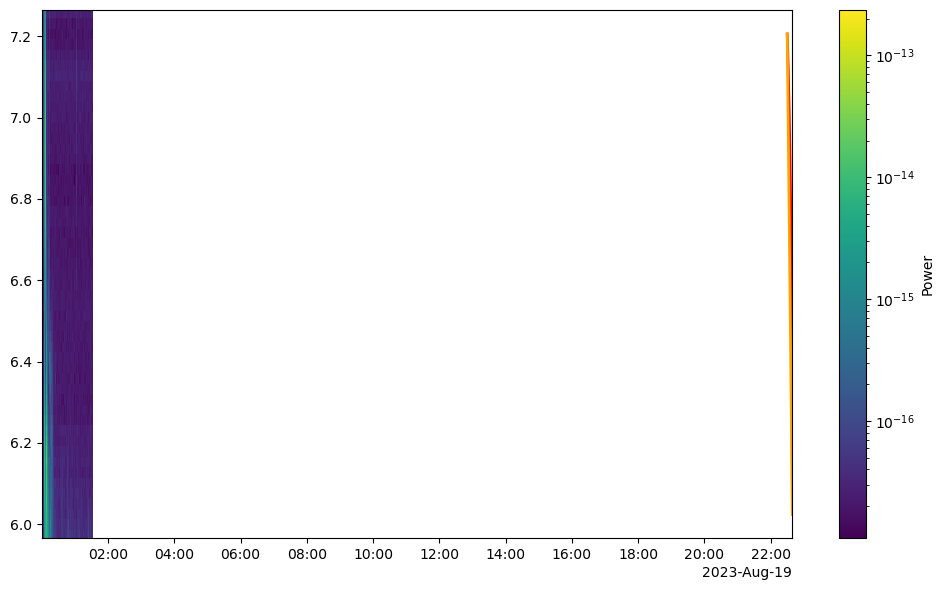

In [882]:
t_plot = times_arr[:800]
Z_plot = data_arr_log[:800, :].T

fig, ax = plt.subplots(figsize=(10, 6))
m = ax.pcolormesh(t_plot, freq_log_exp, Z_plot, norm=LogNorm(), shading="auto")
plt.colorbar(m, ax=ax, label="Power")

ax.plot(UNX_to_UTC(xx), np.log10(yy), color="red", lw=2)
ax.plot(UNX_to_UTC(np.array(x_init)), np.log10(np.array(y_init)), color="orange", lw=2)

# ax.invert_xaxis()
# ax.invert_yaxis()
# ax.set_xlim([t_plot[0], t_plot[-1]])
# ax.set_xlim([UNX_to_UTC(xx)[0], UNX_to_UTC(xx)[-1]])
ax.set_xlim([t_plot[0], UNX_to_UTC(xx)[-1]])

plt.tight_layout()
plt.show()

In [828]:
data_arr.shape

(12359, 128)

In [832]:
(x0, y0), (x1, y1) = longest_line_high
x0=x0+80
x1=x1+80

x_init = (x[800-y1], x[800-y0])
y_init = (y[128-x1], y[128-x0])

xx, yy, flux = ACBone(img, x, y, x_init, y_init, n_iter = 50)
xx, yy, flux

(array([1.69248419e+09, 1.69248419e+09, 1.69248420e+09, 1.69248420e+09,
        1.69248420e+09, 1.69248420e+09, 1.69248420e+09, 1.69248421e+09,
        1.69248421e+09, 1.69248421e+09, 1.69248421e+09, 1.69248421e+09,
        1.69248421e+09, 1.69248422e+09, 1.69248422e+09, 1.69248422e+09,
        1.69248422e+09, 1.69248422e+09, 1.69248423e+09, 1.69248423e+09,
        1.69248423e+09, 1.69248423e+09, 1.69248423e+09, 1.69248424e+09,
        1.69248424e+09, 1.69248424e+09, 1.69248424e+09, 1.69248424e+09,
        1.69248424e+09, 1.69248425e+09, 1.69248425e+09, 1.69248425e+09,
        1.69248425e+09, 1.69248425e+09, 1.69248426e+09, 1.69248426e+09,
        1.69248426e+09, 1.69248426e+09, 1.69248426e+09, 1.69248426e+09,
        1.69248427e+09, 1.69248427e+09, 1.69248427e+09, 1.69248427e+09,
        1.69248427e+09, 1.69248428e+09, 1.69248428e+09, 1.69248428e+09,
        1.69248428e+09, 1.69248428e+09, 1.69248429e+09, 1.69248429e+09,
        1.69248429e+09, 1.69248429e+09, 1.69248429e+09, 1.692484

In [ ]:
t_plot = times_arr[:800]
Z_plot = data_arr_log[:800, :].T

fig, ax = plt.subplots(figsize=(10, 6))
m = ax.pcolormesh(t_plot, freq_log_exp, Z_plot, norm=LogNorm(), shading="auto")
plt.colorbar(m, ax=ax, label="Power")

ax.invert_xaxis()
ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [798]:
def left_pts(lines, times_arr, freq_arr, t_len=800):
    pts_idx = []
    pts_val = []
    seen_x = set()

    for (x0, y0), (x1, y1) in lines:
        # right most
        # xL, yL = x0, y0
        # left most
        x_left, y_left = x1, y1

        if x_left in seen_x:
            continue
        seen_x.add(x_left)

        pts_idx.append((x_left, y_left))
        pts_val.append((times_arr[:t_len][y_left], freq_arr[x_left]))

    pts_idx = np.array(pts_idx, dtype=int)
    pts_val = np.array(pts_val, dtype=object)

    order = np.argsort(pts_val[:, 1].astype(float))[::-1]

    return pts_idx[order], pts_val[order]

pts_idx_left, pts_val_left = left_pts(lines, times_arr, freq_log_exp, t_len=800)
pts_idx_left, pts_val_left

(array([[126,  25],
        [125,  41],
        [124,  25],
        [123,  25],
        [122,  25],
        [121,  30],
        [120,  25],
        [118,  26],
        [117,  26],
        [116,  26],
        [115,  34],
        [113,  26],
        [110,  26],
        [109,  26],
        [107,  27],
        [105,  27],
        [104,  27],
        [101,  28],
        [100,  28],
        [ 99,  28],
        [ 98,  30],
        [ 97,  28],
        [ 96,  29],
        [ 95,  29],
        [ 94,  29],
        [ 93,  29],
        [ 92,  29],
        [ 91,  29],
        [ 90,  30],
        [ 89,  30],
        [ 88,  30],
        [ 87,  37],
        [ 86,  49],
        [ 85,  32],
        [ 84,  32],
        [ 83,  33],
        [ 82,  33],
        [ 81,  34],
        [ 80,  35],
        [ 79,  35],
        [ 78,  35],
        [ 77,  36],
        [ 76,  58],
        [ 75,  39],
        [ 74,  40],
        [ 73,  42],
        [ 72,  43],
        [ 71,  45],
        [ 70,  46],
        [ 69,  49],


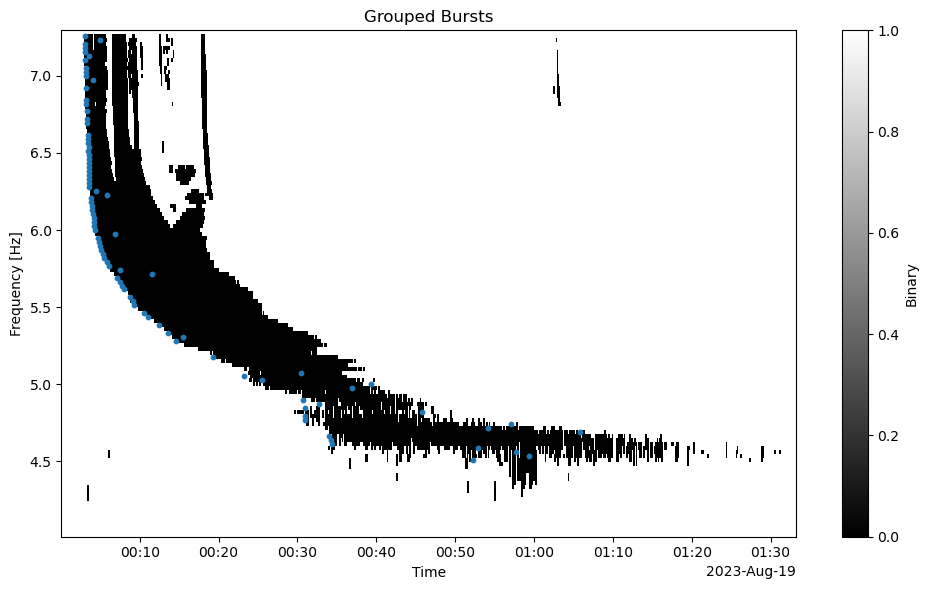

In [800]:
fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap_row_mean_sliced.T
t = times_arr[:800]
f = freq_log_exp

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

ax.scatter(pts_val_left[:,0], pts_val_left[:,1], s=10)

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [802]:
def right_pts(lines, times_arr, freq_arr, t_len=800):
    pts_idx = []
    pts_val = []
    seen_x = set()

    for (x0, y0), (x1, y1) in lines:
        # right most
        x_right, y_right = x0, y0
        # left most
        # x_left, y_left = x1, y1

        if x_right in seen_x:
            continue
        seen_x.add(x_right)

        pts_idx.append((x_right, y_right))
        pts_val.append((times_arr[:t_len][y_right], freq_arr[x_right]))

    pts_idx = np.array(pts_idx, dtype=int)
    pts_val = np.array(pts_val, dtype=object)

    order = np.argsort(pts_val[:, 1].astype(float))[::-1]

    return pts_idx[order], pts_val[order]

pts_idx_right, pts_val_right = right_pts(lines, times_arr, freq_log_exp, t_len=800)
pts_idx_right, pts_val_right

(array([[126, 155],
        [125, 155],
        [124, 155],
        [123, 155],
        [121, 156],
        [119, 154],
        [118, 156],
        [117, 157],
        [116, 157],
        [115, 157],
        [114, 157],
        [112, 154],
        [111, 157],
        [108, 155],
        [107, 158],
        [105, 158],
        [104, 158],
        [ 99, 159],
        [ 91, 156],
        [ 90, 162],
        [ 89, 163],
        [ 88, 162],
        [ 87, 160],
        [ 86, 164],
        [ 85, 164],
        [ 84, 156],
        [ 83, 152],
        [ 82, 155],
        [ 80, 155],
        [ 79, 154],
        [ 78, 153],
        [ 77, 150],
        [ 75, 157],
        [ 74, 156],
        [ 73, 156],
        [ 72, 157],
        [ 71, 160],
        [ 69, 165],
        [ 67, 171],
        [ 66, 181],
        [ 64, 176],
        [ 62, 202],
        [ 60, 208],
        [ 59, 204],
        [ 58, 217],
        [ 55, 223],
        [ 52, 230],
        [ 51, 267],
        [ 50, 277],
        [ 49, 179],


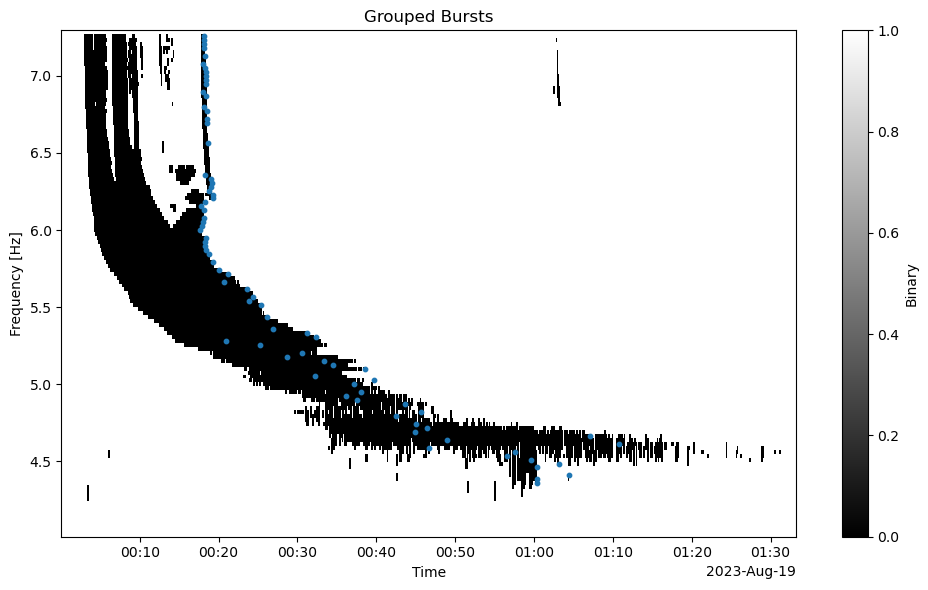

In [804]:
fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap_row_mean_sliced.T
t = times_arr[:800]
f = freq_log_exp

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

ax.scatter(pts_val_right[:,0], pts_val_right[:,1], s=10)

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

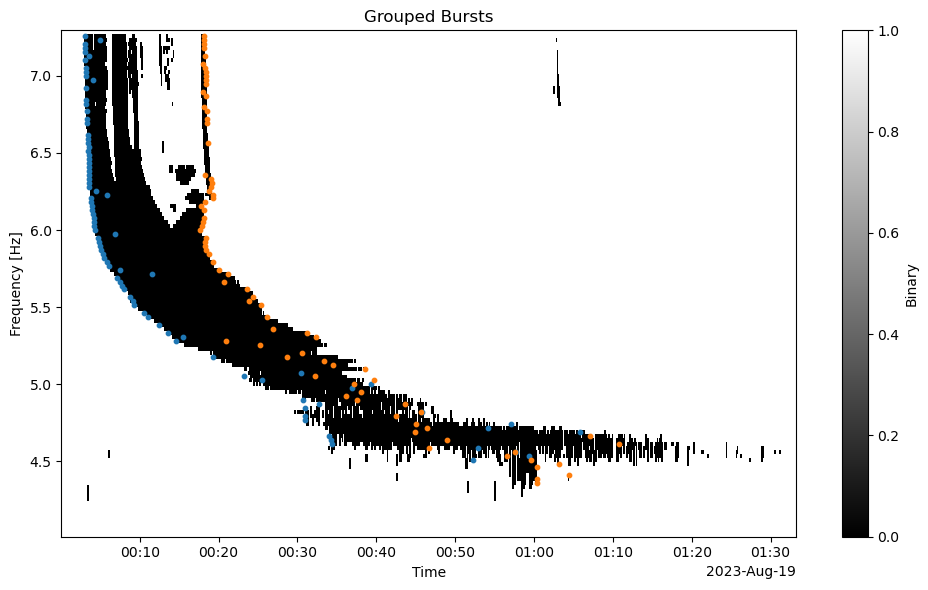

In [806]:
fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap_row_mean_sliced.T
t = times_arr[:800]
f = freq_log_exp

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

ax.scatter(pts_val_left[:,0], pts_val_left[:,1], s=10)
ax.scatter(pts_val_right[:,0], pts_val_right[:,1], s=10)

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()

In [910]:
pts_idx_left, pts_val_left = left_pts(lines_low, times_arr, freq_log_exp[:40], t_len=800)
pts_idx_right, pts_val_right = right_pts(lines_low, times_arr, freq_log_exp[:40], t_len=800)
pts_idx_left, pts_val_left

(array([[ 39, 204],
        [ 38, 209],
        [ 36, 311],
        [ 34, 263],
        [ 32, 265],
        [ 31, 253],
        [ 29, 265],
        [ 28, 405],
        [ 27, 524],
        [ 26, 454],
        [ 25, 291],
        [ 24, 293],
        [ 22, 422],
        [ 21, 469]]),
 array([[numpy.datetime64('2023-08-19T00:23:52.890183808'),
         5.024085491661012],
        [numpy.datetime64('2023-08-19T00:24:27.842580224'),
         4.998419817977064],
        [numpy.datetime64('2023-08-19T00:36:20.876105856'),
         4.947088470609169],
        [numpy.datetime64('2023-08-19T00:30:45.330903040'),
         4.895757123241275],
        [numpy.datetime64('2023-08-19T00:30:59.311861632'),
         4.844425775873379],
        [numpy.datetime64('2023-08-19T00:29:35.425621888'),
         4.818760102189432],
        [numpy.datetime64('2023-08-19T00:30:59.311861632'),
         4.7674287548215375],
        [numpy.datetime64('2023-08-19T00:47:17.985064832'),
         4.74176308113759],
      

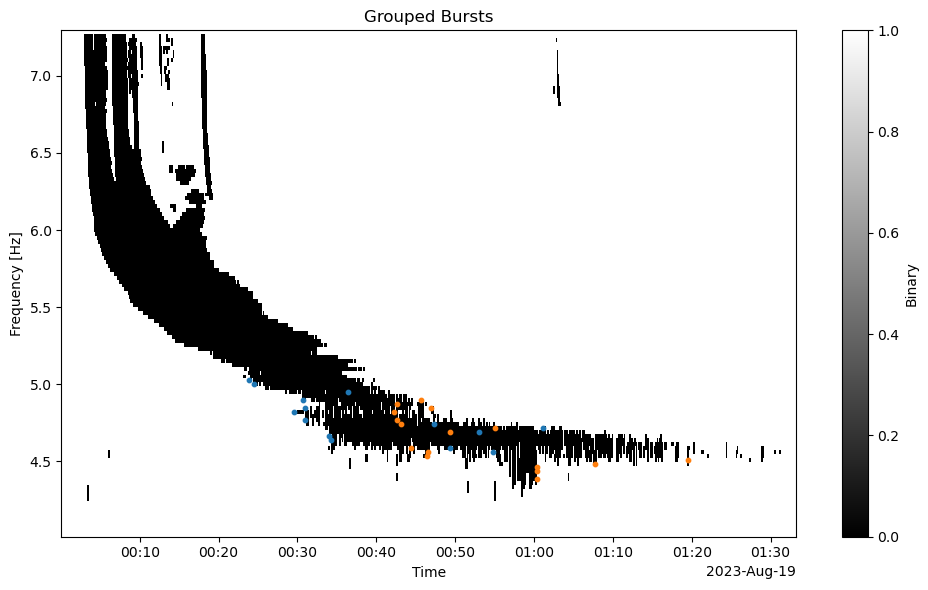

In [914]:
fig, ax = plt.subplots(figsize=(10, 6))
Z = 1 - bmap_row_mean_sliced.T
t = times_arr[:800]
f = freq_log_exp

p = ax.pcolormesh(t, f, Z, shading="auto", cmap="gray")
plt.colorbar(p, ax=ax, label="Binary")

ax.scatter(pts_val_left[:,0], pts_val_left[:,1], s=10)
ax.scatter(pts_val_right[:,0], pts_val_right[:,1], s=10)

plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
# plt.yscale('log')
plt.title("Grouped Bursts")
# plt.grid(True)
plt.tight_layout()
plt.show()